In [1]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.callbacks import Callback
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM, Dropout, TimeDistributed, Input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.models import load_model


pd.options.display.max_rows = 99999
pd.options.display.max_colwidth = 99999
print(tf.config.list_physical_devices('GPU'))

[]


In [4]:
# ULTILITY FUNCTION
# UNIVARIATE VERSION
def create_sequence(mtx, timestep:int):
  x = []
  y = []
  window = timestep + 1

  for i in range(mtx.shape[0] - window + 1):
    sample = mtx[i: i+window]
    x.append(sample[:-1])
    y.append(sample[-1])

  return np.asarray(x), np.asarray(y)

# RESET STATES BETWEEN EPOCHS
class ResetStatesCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        self.model.reset_states()

In [5]:
tetouan = pd.read_csv("final_tetouan.csv")
tetouan['DateTime'] = pd.to_datetime(tetouan["DateTime"], format='mixed')
tetouan = tetouan.set_index('DateTime')

display(tetouan.head())
display(tetouan.info())

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Hours,Weekdays,Months,Days of Year
DateTime,,,,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0,6,1,1
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0,6,1,1
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0,6,1,1
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0,6,1,1
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0,6,1,1


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52416 entries, 2017-01-01 00:00:00 to 2017-12-30 23:50:00
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature                52416 non-null  float64
 1   Humidity                   52416 non-null  float64
 2   Wind Speed                 52416 non-null  float64
 3   general diffuse flows      52416 non-null  float64
 4   diffuse flows              52416 non-null  float64
 5   Zone 1 Power Consumption   52416 non-null  float64
 6   Zone 2  Power Consumption  52416 non-null  float64
 7   Zone 3  Power Consumption  52416 non-null  float64
 8   Hours                      52416 non-null  int64  
 9   Weekdays                   52416 non-null  int64  
 10  Months                     52416 non-null  int64  
 11  Days of Year               52416 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 5.2 MB


None

In [6]:
# First split
train_size = int(tetouan.shape[0]*0.75)

z2 = tetouan['Zone 2  Power Consumption'].copy()
X, y_test = z2[:train_size + 1], z2[train_size:].values.reshape(-1,1)

# Why train_size + 1 ?
# Because using the last tensor in training set to forecast future timesteps

In [7]:
# Fit MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1,1)).fit(X.values.reshape(-1,1))

In [80]:
# Scaling & tensorization
timesteps = 144

X_train, y_train = create_sequence(scaler.transform(X.values.reshape(-1,1)), timesteps)

latest_tensor = X_train[-1]
X_train = X_train[:-1]
y_train = y_train[:-1]

display(X_train.shape)
display(y_train.shape)
display(y_train)

(39168, 144, 1)

(39168, 1)

array([[-0.34227131],
       [-0.37969526],
       [-0.4064989 ],
       ...,
       [-0.25916641],
       [-0.29081758],
       [-0.32220932]], shape=(39168, 1))

In [98]:
tf.keras.backend.clear_session()

lstm_z2 = Sequential([
    Input(batch_shape=(1, timesteps, 1)),
    LSTM(128, activation='tanh', kernel_initializer='glorot_normal', stateful=True, seed=26, return_sequences=False),
    Dense(64, activation='tanh', kernel_initializer='glorot_normal'),
    Dense(1, activation='tanh', kernel_initializer='glorot_normal')
])

In [99]:
lstm_z2.compile(optimizer=Adam(learning_rate=0.001, ema_momentum=0.9), loss='mae')
lstm_z2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (1, 128)               │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,881 (292.50 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#call_back = EarlyStopping(patience=5, restore_best_weights=True, start_from_epoch=10)

epochs = 1

for _ in range(epochs):
  lstm_z2_fit = lstm_z2.fit(
      x=X_train, y=y_train,
      batch_size=1,
      validation_split=0.1,
      verbose=1,
      shuffle = False,
  )
  for layer in lstm_z2.layers:
      if hasattr(layer, "reset_states"):
          layer.reset_states()

lstm_z2.save("uni_lstm_z2.keras")

In [91]:
model_z2 = load_model("uni_lstm_z2.keras")
model_z2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (1, 128)               │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,645 (877.52 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 149,764 (585.02 KB)

In [92]:
# Similar to ARIMA forecast (no feeding input)
# Using the latest tensor in training as starting set to forecast.
# latest training tensor forecast the first timestamp in testing set.

def multistep_forecast(model, start, steps:int):
  for layer in model.layers:
      if hasattr(layer, "reset_states"):
          layer.reset_states()

  cp_start = start.copy()
  forecast_vals = []

  for step in range(steps):
    pred = model.predict(np.array([cp_start]), verbose=0)

    forecast_vals.append(pred[0][0])
    cp_start = np.delete(cp_start, 0, axis=0)
    cp_start = np.append(cp_start, pred, axis=0)

  return np.array(forecast_vals).reshape(-1,1)

In [93]:
# Only forecast limited steps.
# Running time is very long for long steps.
pred = multistep_forecast(model_z2, start=latest_tensor, steps=800)
print(pred.shape)

(800, 1)


In [94]:

pred_org = scaler.inverse_transform(pred)
print(root_mean_squared_error(pred_org, y_test[:800]))
print(mean_absolute_error(pred_org, y_test[:800]))


5145.367922237576
4025.644422670703


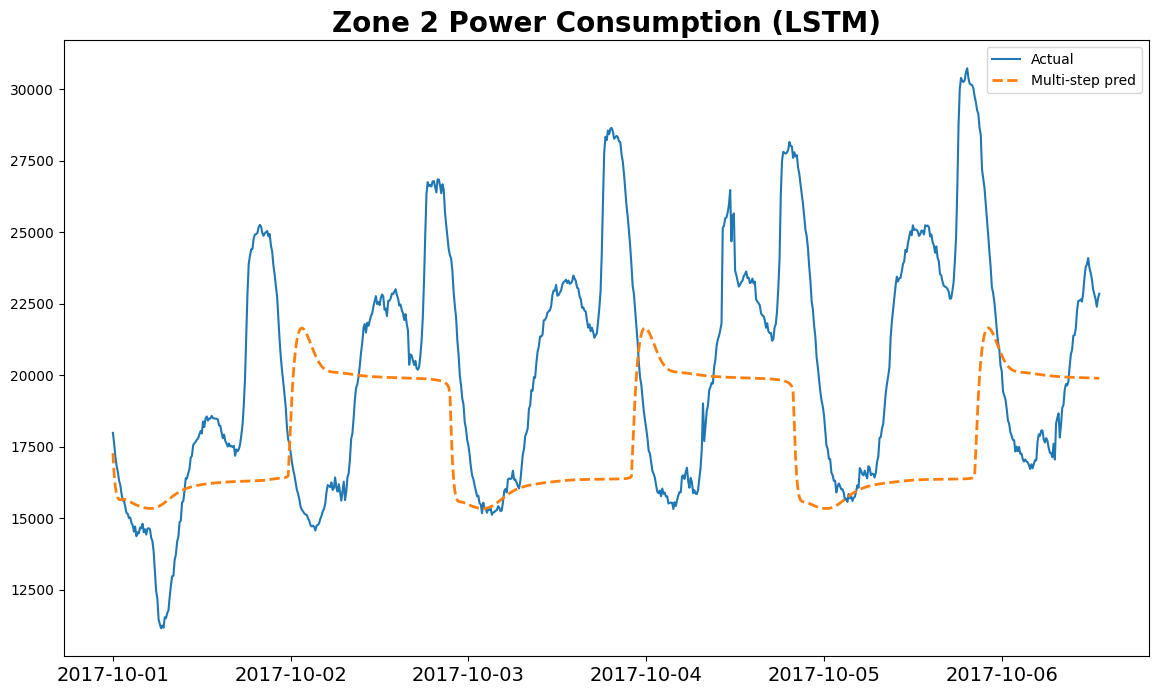

In [95]:
index = tetouan.index[train_size:][:800]

plt.figure(figsize=(14,8))
plt.plot(index, y_test[:800], label="Actual")
plt.plot(index, pred_org[:800], ls='--', lw=2, label="Multi-step pred")
plt.title("Zone 2 Power Consumption (LSTM)", fontsize=20, fontweight='bold')
plt.xticks(fontsize=14)
plt.legend()
plt.show()